In [74]:
import os
import re
import pickle
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.corpus import stopwords
import spacy
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm

from scipy.sparse import csr_matrix
from gensim import corpora, models
from gensim.matutils import Sparse2Corpus

from scipy.stats import pearsonr
from scipy import sparse

import wordcloud
from wordcloud import WordCloud

In [69]:
import os
import subprocess
subprocess.Popen(['caffeinate', '-i', '-w', str(os.getpid())])
print("Caffeinate running — laptop won't sleep")

Caffeinate running — laptop won't sleep


In [2]:
# Function to download NLTK resources
def download_nltk_resources():
    required_resources = ['wordnet', 'stopwords', 'punkt', 'punkt_tab']
    for resource in required_resources:
        try:
            nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

# Load spaCy model; if missing, install it in the current Jupyter kernel environment.
try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download

    print("Installing spaCy model 'en_core_web_sm' for this environment...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

# Enable tqdm for pandas
tqdm.pandas()

# Initialize stemmers and lemmatizer
porter = SnowballStemmer("english")
lmtzr = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bertielamb/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bertielamb/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
"""
This module provides helper functions for text preprocessing. 
Each function applies punctuation removal and stopword removal, and then one of three options:
    0: Lowercasing only.
    1: Lowercasing plus stemming.
    2: Lemmatizing (using spaCy; original casing is preserved).

The functions return a string of tokens separated by spaces.
"""

def preprocess_lower(text):
    """
    Preprocess text by:
       - Converting to lowercase.
       - Removing punctuation.
       - Tokenizing.
       - Removing stopwords.
    
    Returns:
        str: A string of filtered tokens separated by spaces.
    """
    text_lower = text.lower()
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)
    tokens = word_tokenize(text_no_punct)
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(filtered_tokens)

def preprocess_stem(text):
    """
    Preprocess text by performing all steps in preprocess_lower() and then applying stemming.
    
    Returns:
        str: A string of stemmed tokens separated by spaces.
    """
    tokens = preprocess_lower(text).split()
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

def preprocess_lemma(text):
    """
    Preprocess text by:
       - Removing punctuation and stopwords using spaCy's token attributes.
       - Lemmatizing the text.
       - (Note: This function does NOT lowercase the text.)
    
    Returns:
        str: A string of lemmatized tokens separated by spaces.
    """
    doc = sp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']
    return " ".join(lemmatized_tokens)

def tokenize(text, mode=0):
    """
    General tokenize function. Always applies punctuation and stopword removal and then:
    
      mode = 0: Applies lowercasing.
      mode = 1: Applies lowercasing and stemming.
      mode = 2: Applies lemmatization (without lowercasing the original text).
    
    Args:
        text (str): The input text to be processed.
        mode (int): Processing mode (0 for lowercasing; 1 for stemming; 2 for lemmatizing).

    Returns:
        str: A string of processed tokens separated by spaces.

    Raises:
        ValueError: If an invalid mode is provided.
    """
    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")


In [4]:
data_file = 'hansard.csv'
corpus_data = pd.read_csv(data_file, encoding='utf-8')

corpus_data = corpus_data.dropna(subset='speaker')
corpus_data.drop(columns=["file","speech_id","type","speaker_id", "colnum","time","url"], 
                 inplace=True)

corpus_data.info()
corpus_data.head()

/var/folders/sh/fyg2xxg50qxf8s19d34bzy2c0000gn/T/ipykernel_86876/1378335376.py:2: DtypeWarning: Columns (0: type, 1: speaker_id, 2: colnum, 3: url) have mixed types. Specify dtype option on import or set low_memory=False.
  corpus_data = pd.read_csv(data_file, encoding='utf-8')


<class 'pandas.DataFrame'>
Index: 4328210 entries, 5 to 4671401
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   date        str  
 1   speaker     str  
 2   section     str  
 3   text        str  
 4   word_count  int64
dtypes: int64(1), str(4)
memory usage: 198.1 MB


,date,speaker,section,text,word_count
5,1952-01-29,Mr. Stephen Swingler,Re-armament and Essential Industries,asked the Minister of Labour whether he will m...,20
6,1952-01-29,Mr. Norman Dodds,Re-armament and Essential Industries,asked the Minister of Labour what proposals he...,26
7,1952-01-29,The Minister of Labour (Sir Walter Monckton),Re-armament and Essential Industries,I would ask the hon. Members to await the stat...,34
8,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,asked the Minister of Labour what numbers of p...,28
9,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,I regret that it is not practicable to make su...,12


In [5]:
data_file = 'UK_monarch_speeches.csv'
monarch_data = pd.read_csv(data_file, encoding='utf-8')

monarch_data.drop(columns=["year","title","url"], 
                 inplace=True)
monarch_data.rename(columns={"monarch": "speaker", "speech": "text"}, inplace=True)
monarch_data['section'] = 'Monarch speech identifier'
monarch_data["word_count"] = monarch_data["text"].apply(lambda x: len(x.split()))

monarch_data.info()
monarch_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        433 non-null    str  
 1   speaker     433 non-null    str  
 2   text        433 non-null    str  
 3   section     433 non-null    str  
 4   word_count  433 non-null    int64
dtypes: int64(1), str(4)
memory usage: 17.0 KB


,date,speaker,text,section,word_count
0,1952-12-25,Queen Elizabeth II,"Each Christmas, at this time, my beloved fathe...",Monarch speech identifier,690
1,1953-06-02,Queen Elizabeth II,"When I spoke to you last, at Christmas, I aske...",Monarch speech identifier,641
2,1953-06-02,Queen Elizabeth II,"In the Coronation ceremony of 2 June 1953, one...",Monarch speech identifier,451
3,1953-12-25,Queen Elizabeth II,Last Christmas I spoke to you from England; th...,Monarch speech identifier,900
4,1954-12-25,Queen Elizabeth II,It is now two years since my husband and I spe...,Monarch speech identifier,641


In [6]:
corpus_data = pd.concat([corpus_data, monarch_data], ignore_index=True)
corpus_data.tail()

,date,speaker,section,text,word_count
4328638,2025-12-12,King Charles III,Monarch speech identifier,This is a season when our thoughts turn to cel...,636
4328639,2025-12-19,King Charles III,Monarch speech identifier,"Ladies and gentlemen, I am delighted to be abl...",886
4328640,2026-02-11,King Charles III,Monarch speech identifier,My wife and I were profoundly shocked and sadd...,365
4328641,2026-02-12,King Charles III,Monarch speech identifier,So to those who provide care - whether you wea...,754
4328642,2026-02-18,King Charles III,Monarch speech identifier,My wife and I were deeply saddened to hear of ...,96


In [7]:
# WATCH OUT this will take time 10 Minutes roughly
# Set mode (0 = lowercasing, 1 = stemming, 2 = lemmatizing)
mod = 1

# Pre-process the text column with progress tracking
try:
    corpus_data["text"] = corpus_data.text.astype(str).progress_apply(lambda row: tokenize(row, mod))
    corpus_data["word_count"] = corpus_data.text.progress_apply(lambda x: len(x.split()))
    print("Done processing text.")
except Exception as e:
    print(f"Error processing text column: {e}")
    raise RuntimeError(f"Error processing text column: {e}") from e

100%|██████████| 4328643/4328643 [00:05<00:00, 758996.68it/s] 

Done processing text.


In [8]:
#checkpoint 1
corpus_data.to_csv("speeches_processed.csv", index=False)

In [9]:
data_file = 'speeches_processed.csv'
corpus_data = pd.read_csv(data_file, encoding='utf-8')
corpus_data = corpus_data[corpus_data['word_count']>20]
corpus_data.reset_index(drop=True, inplace=True)

In [ ]:
cv = CountVectorizer(ngram_range = (1,2), lowercase=True, min_df=0.005, max_df=0.7)
cv.fit(corpus_data["text"])
vectorized_text=cv.transform(corpus_data["text"])
vectorized_text.shape

(2566390, 1791)

In [ ]:
# Checkpoint 2
sparse.save_npz('vectorized_text.npz', vectorized_text)
with open('cv_vectorizer.pkl', 'wb') as f:
    pickle.dump(cv, f)

In [14]:
# Load
vectorized_text = sparse.load_npz('vectorized_text.npz')
with open('cv_vectorizer.pkl', 'rb') as f:
    cv = pickle.load(f)

In [19]:
#gensim needs the dtm in a different sparce format
dtm_sparse = csr_matrix(vectorized_text)

# Convert sparse matrix to gensim corpus
corpus = Sparse2Corpus(dtm_sparse, documents_columns=False)

# Create gensim dictionary from sklearn CountVectorizer vocabulary
vocabulary_gensim = {}
for key, val in cv.vocabulary_.items():
    vocabulary_gensim[val] = key

dictionary = corpora.Dictionary()
dictionary.id2token = vocabulary_gensim
dictionary.token2id = cv.vocabulary_

In [26]:
help(models.LdaMulticore)

Help on class LdaMulticore in module gensim.models.ldamulticore:

class LdaMulticore(gensim.models.ldamodel.LdaModel)
 |  LdaMulticore(
 |      corpus=None,
 |      num_topics=100,
 |      id2word=None,
 |      workers=None,
 |      chunksize=2000,
 |      passes=1,
 |      batch=False,
 |      alpha='symmetric',
 |      eta=None,
 |      decay=0.5,
 |      offset=1.0,
 |      eval_every=10,
 |      iterations=50,
 |      gamma_threshold=0.001,
 |      random_state=None,
 |      minimum_probability=0.01,
 |      minimum_phi_value=0.01,
 |      per_word_topics=False,
 |      dtype=<class 'numpy.float32'>
 |  )
 |
 |  An optimized implementation of the LDA algorithm, able to harness the power of multicore CPUs.
 |  Follows the similar API as the parent class :class:`~gensim.models.ldamodel.LdaModel`.
 |
 |  Method resolution order:
 |      LdaMulticore
 |      gensim.models.ldamodel.LdaModel
 |      gensim.interfaces.TransformationABC
 |      gensim.utils.SaveLoad
 |      gensim.models.b

In [31]:
# Number of topics
num_topics =25
workers = 8
# Build LDA model
lda_model = models.LdaMulticore(corpus=corpus, 
                            id2word=dictionary, 
                            num_topics=num_topics,
                            workers = workers, 
                            passes=20,
                            random_state=123)

In [70]:
topic_sizes = [8, 5, 10, 15, 25]

for num_topics in tqdm(topic_sizes, desc="Training LDA models"):
    print(f"\nTraining model with {num_topics} topics...")
    
    lda_model = models.LdaMulticore(corpus=corpus,
                                    id2word=dictionary,
                                    num_topics=num_topics,
                                    workers=8,
                                    passes=20,
                                    random_state=123)
    
    # Save checkpoint
    with open(f'lda_model_{num_topics}_topics.pkl', 'wb') as f:
        pickle.dump(lda_model, f)
    
    print(f"Saved lda_model_{num_topics}_topics.pkl")

print("\nAll models trained and saved")

Training LDA models:   0%|          | 0/5 [00:00<?, ?it/s]


Training model with 8 topics...


Training LDA models:  20%|██        | 1/5 [1:12:51<4:51:25, 4371.41s/it]

Saved lda_model_8_topics.pkl

Training model with 5 topics...


Training LDA models:  40%|████      | 2/5 [2:25:42<3:38:34, 4371.47s/it]

...

Saved lda_model_10_topics.pkl

Training model with 15 topics...


Training LDA models:  80%|████████  | 4/5 [4:50:32<1:12:34, 4354.22s/it]

Saved lda_model_15_topics.pkl

Training model with 25 topics...


Training LDA models: 100%|██████████| 5/5 [6:01:38<00:00, 4339.63s/it]  

Saved lda_model_25_topics.pkl

All models trained and saved


In [36]:
# Display the topics
topics = lda_model.print_topics(num_words=50)
for topic in topics:
    print(topic)
    print("    ")

(np.int64(19), '0.063*"peopl" + 0.022*"mani" + 0.021*"work" + 0.019*"constitu" + 0.016*"live" + 0.014*"get" + 0.014*"countri" + 0.012*"need" + 0.011*"time" + 0.010*"one" + 0.009*"famili" + 0.008*"want" + 0.008*"go" + 0.008*"job" + 0.008*"know" + 0.008*"problem" + 0.007*"across" + 0.007*"hous" + 0.006*"help" + 0.006*"come" + 0.006*"support" + 0.006*"face" + 0.006*"see" + 0.006*"us" + 0.006*"make" + 0.006*"day" + 0.005*"today" + 0.005*"number" + 0.005*"back" + 0.005*"commun" + 0.005*"life" + 0.005*"also" + 0.005*"issu" + 0.005*"like" + 0.005*"place" + 0.005*"much" + 0.005*"take" + 0.005*"even" + 0.004*"huge" + 0.004*"everi" + 0.004*"look" + 0.004*"right" + 0.004*"global" + 0.004*"week" + 0.004*"must" + 0.004*"around" + 0.004*"long" + 0.004*"still" + 0.004*"often" + 0.004*"pay"')
    
(np.int64(16), '0.085*"hous" + 0.046*"committe" + 0.036*"debat" + 0.025*"report" + 0.019*"leader" + 0.016*"time" + 0.016*"govern" + 0.012*"select" + 0.012*"leader hous" + 0.011*"lord" + 0.011*"matter" + 0.01

In [ ]:


topic_sizes = [5, 8, 10, 15, 25]

for num_topics in topic_sizes:
    with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'rb') as f:
        lda_model = pickle.load(f)
    
    print(f"MODEL: {num_topics} TOPICS")
    
    topics = lda_model.print_topics(num_words=50)
    for topic in topics:
        print(topic)
        print()


MODEL: 5 TOPICS
(0, '0.018*"state" + 0.017*"secretari" + 0.016*"minist" + 0.015*"govern" + 0.013*"secretari state" + 0.013*"uk" + 0.011*"prime" + 0.010*"countri" + 0.010*"prime minist" + 0.008*"unit" + 0.007*"european" + 0.007*"northern" + 0.007*"ireland" + 0.007*"trade" + 0.007*"intern" + 0.007*"union" + 0.007*"nation" + 0.007*"british" + 0.006*"eu" + 0.006*"northern ireland" + 0.006*"us" + 0.006*"secur" + 0.006*"right" + 0.006*"world" + 0.005*"support" + 0.005*"scotland" + 0.005*"forc" + 0.005*"kingdom" + 0.005*"defenc" + 0.005*"unit kingdom" + 0.004*"continu" + 0.004*"take" + 0.004*"foreign" + 0.004*"import" + 0.004*"scottish" + 0.004*"peopl" + 0.004*"agre" + 0.004*"would" + 0.004*"agreement" + 0.004*"need" + 0.004*"also" + 0.004*"make" + 0.004*"work" + 0.003*"commit" + 0.003*"part" + 0.003*"must" + 0.003*"ensur" + 0.003*"negoti" + 0.003*"arm" + 0.003*"made"')

(1, '0.103*"hon" + 0.054*"friend" + 0.049*"hon friend" + 0.040*"right" + 0.027*"right hon" + 0.026*"gentleman" + 0.025*"ho

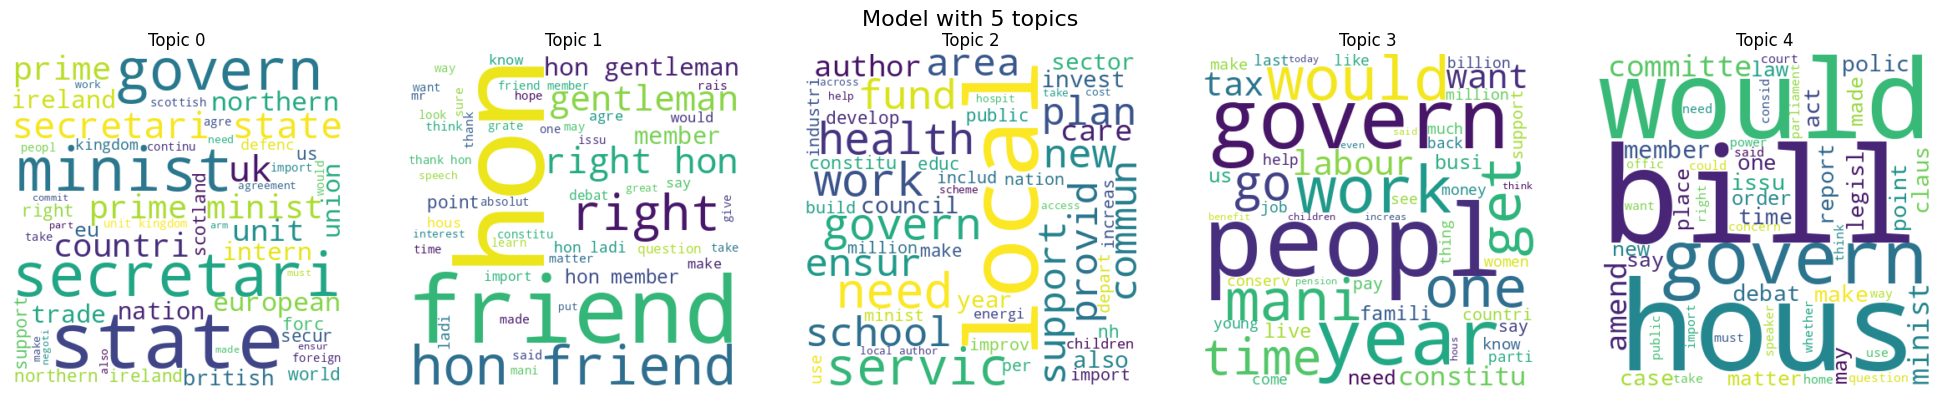

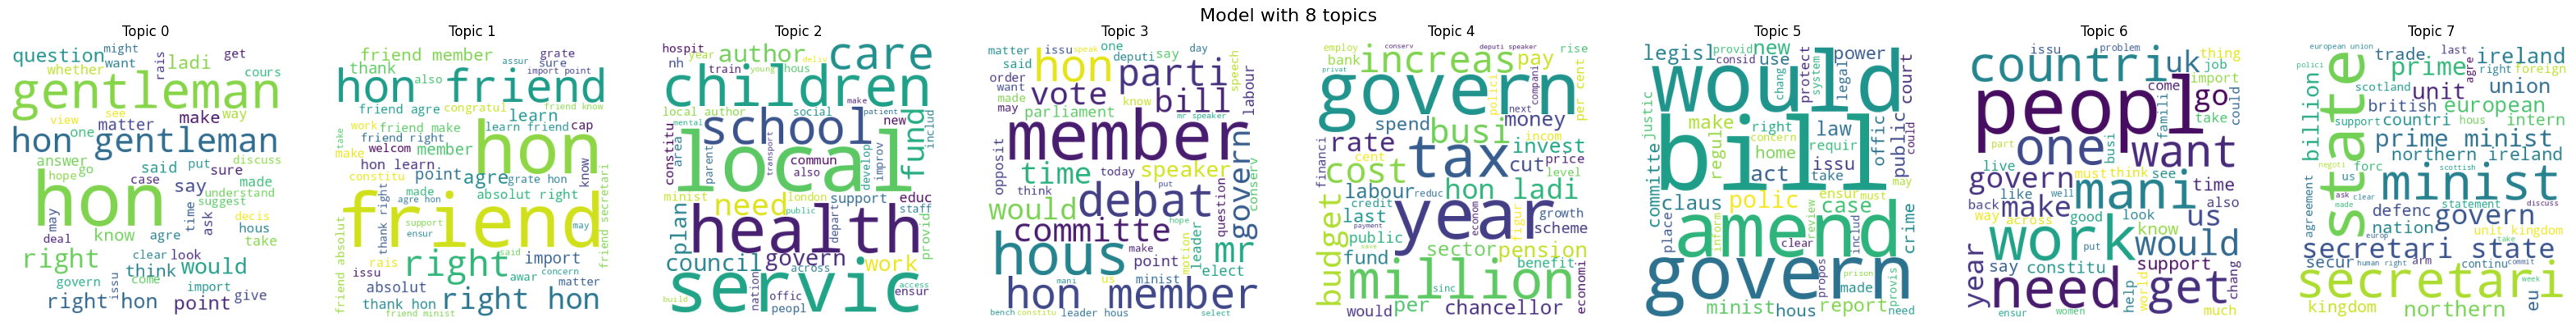

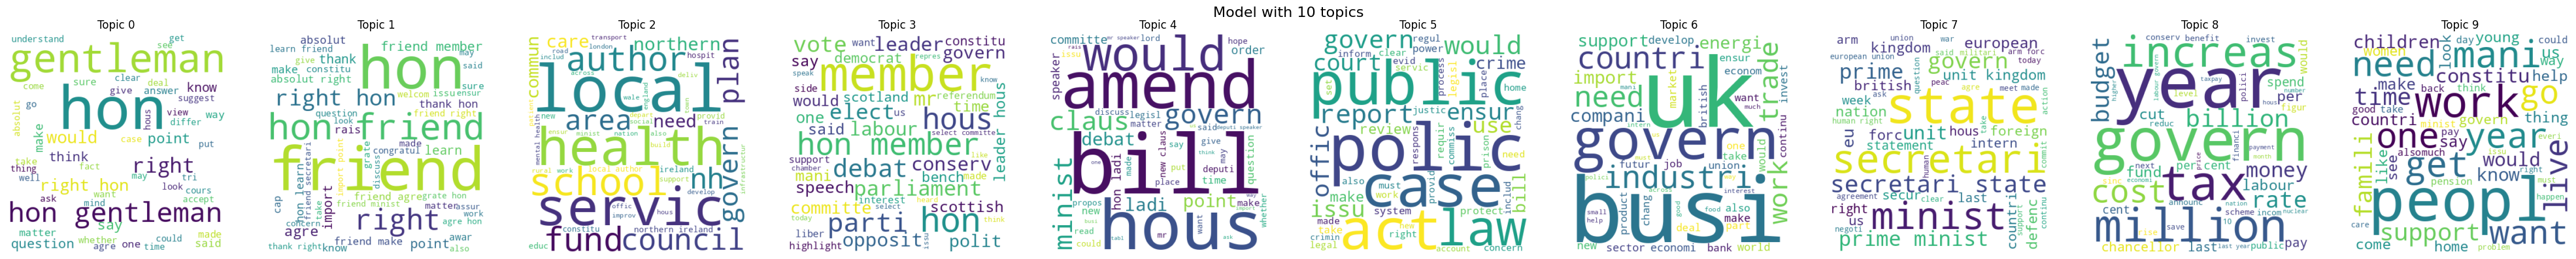

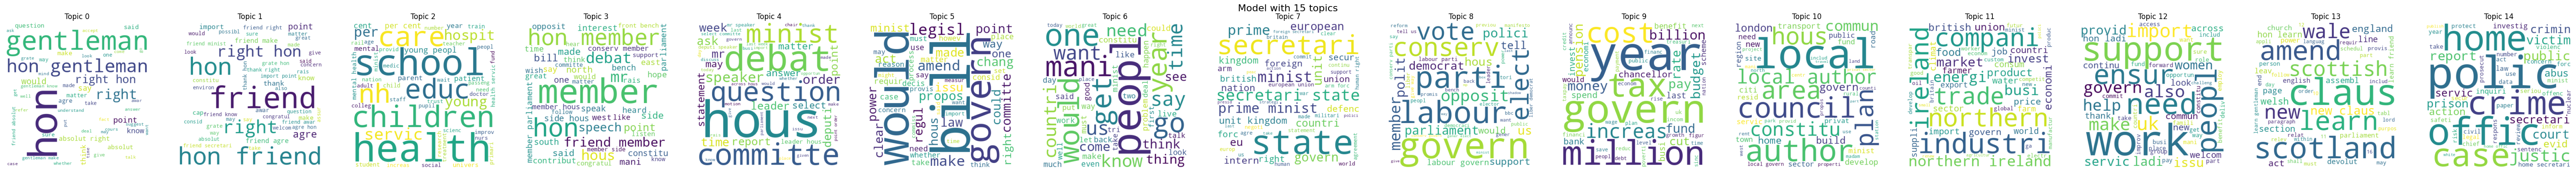

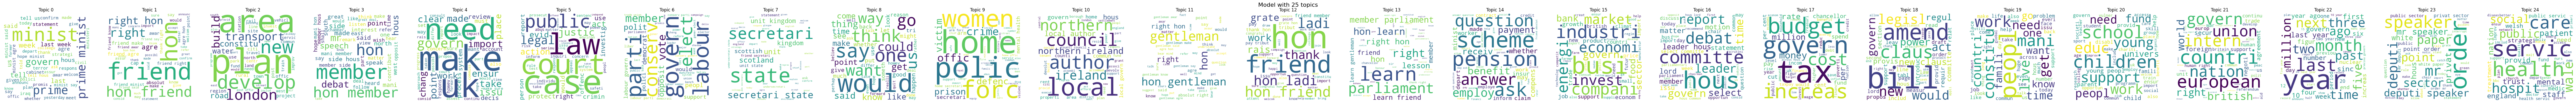

In [78]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

topic_sizes = [5, 8, 10, 15, 25]

for num_topics in topic_sizes:
    with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'rb') as f:
        lda_model = pickle.load(f)
    
    fig, axes = plt.subplots(1, num_topics, figsize=(num_topics * 4, 4))
    fig.suptitle(f'Model with {num_topics} topics', fontsize=16)
    
    for topic_id in range(num_topics):
        # parse "0.012*"word" + 0.011*"word2"..." into dict
        topic_terms = lda_model.show_topic(topic_id, topn=50)
        word_freq = {word: weight for word, weight in topic_terms}
        
        wc = WordCloud(width=400, height=400, background_color='white')
        wc.generate_from_frequencies(word_freq)
        
        ax = axes[topic_id] if num_topics > 1 else axes
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Topic {topic_id}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'wordcloud_{num_topics}_topics.png', dpi=150, bbox_inches='tight')
    plt.show()

In [45]:
print(topics[16])

(np.int64(9), '0.057*"home" + 0.054*"polic" + 0.038*"forc" + 0.036*"women" + 0.029*"crime" + 0.028*"offic" + 0.021*"victim" + 0.021*"defenc" + 0.020*"prison" + 0.019*"secretari" + 0.016*"arm" + 0.015*"mental health" + 0.014*"home secretari" + 0.013*"servic" + 0.012*"arm forc" + 0.011*"support" + 0.011*"violenc" + 0.010*"men" + 0.009*"fire" + 0.009*"secur" + 0.009*"home offic" + 0.008*"safe" + 0.008*"drug" + 0.007*"commun" + 0.007*"serv" + 0.007*"commit" + 0.006*"royal" + 0.006*"domest" + 0.006*"work" + 0.006*"abus" + 0.006*"ensur" + 0.006*"justic" + 0.006*"armi" + 0.006*"also" + 0.005*"street" + 0.005*"protect" + 0.005*"number" + 0.005*"immigr" + 0.005*"oper" + 0.005*"famili" + 0.005*"attack" + 0.005*"tackl" + 0.005*"chief" + 0.005*"need" + 0.005*"ministri" + 0.004*"militari" + 0.004*"includ" + 0.004*"crimin" + 0.004*"recruit" + 0.004*"murder"')


In [33]:
doc_topics = [lda_model.get_document_topics(item, minimum_probability=0.0000001) for item in corpus]

# Initialize the columns for each topic with default value 0
for topic_num in range(num_topics):
    corpus_data[f'topic_{topic_num}'] = 0.0

# Iterate over the document topics to fill the DataFrame
for i, doc_distribution in enumerate(doc_topics):
    for topic_num, prob in doc_distribution:
        corpus_data.at[i, f'topic_{topic_num}'] = prob


In [34]:
corpus_data.head()

,date,speaker,section,text,word_count,topic_0,topic_1,topic_2,topic_3,topic_4,...,topic_15,topic_16,topic_17,topic_18,topic_19,topic_20,topic_21,topic_22,topic_23,topic_24
0,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,view fact minist made number statement speech ...,22,0.091840,0.001905,0.001905,0.064200,0.241494,...,0.110253,0.001905,0.001905,0.001905,0.001905,0.001905,0.001905,0.001905,0.001905,0.001905
1,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,difficulti make estim chang occup peopl precis...,27,0.001667,0.001667,0.001667,0.001667,0.001667,...,0.001667,0.001667,0.001667,0.001667,0.536890,0.001667,0.001667,0.001667,0.001667,0.001667
2,1952-01-29,Sir W. Monckton,Coalmining (Italian Workers),presum hon member refer italian worker brought...,24,0.001905,0.001905,0.001905,0.202916,0.001905,...,0.001905,0.001905,0.001905,0.001905,0.300023,0.001905,0.001905,0.001905,0.001905,0.001905
3,1952-01-29,Sir W. Monckton,Textiles and Clothing,latest date figur avail 10th decemb date 7379 ...,39,0.001429,0.001429,0.001429,0.001429,0.001429,...,0.001429,0.001429,0.001429,0.001429,0.001429,0.001429,0.188914,0.147799,0.001429,0.040207
4,1952-01-29,Sir W. Monckton,Textiles and Clothing,refer temporari phase due fact earli decemb nu...,43,0.001000,0.204641,0.001000,0.001000,0.001000,...,0.051143,0.001000,0.131756,0.001000,0.178604,0.001000,0.001000,0.001000,0.001000,0.001000


In [41]:
topic_cols = [col for col in corpus_data.columns if col.startswith('topic_')]


daily_sum = corpus_data.assign(
    **{col: corpus_data[col] * corpus_data['word_count'] for col in topic_cols}
).groupby('date')[topic_cols + ['word_count']].sum()


final_daily_vectors = daily_sum[topic_cols].div(daily_sum['word_count'], axis=0).reset_index()

print(final_daily_vectors.head())

         date   topic_0   topic_1   topic_2   topic_3   topic_4   topic_5  \
0  1952-01-29  0.016976  0.036499  0.050487  0.079871  0.033261  0.068413   
1  1952-01-30  0.035465  0.023914  0.021078  0.095713  0.036317  0.042135   
2  1952-01-31  0.019934  0.052188  0.014533  0.110877  0.031274  0.042468   
3  1952-02-01  0.014019  0.022180  0.004950  0.178277  0.020220  0.092474   
4  1952-02-04  0.034374  0.034802  0.033821  0.118821  0.037879  0.055255   

    topic_6   topic_7   topic_8  ...  topic_15  topic_16  topic_17  topic_18  \
0  0.006446  0.040792  0.136873  ...  0.043918  0.045089  0.064569  0.033165   
1  0.036387  0.028386  0.136520  ...  0.039828  0.079501  0.052949  0.011863   
2  0.026418  0.017508  0.115257  ...  0.052699  0.047872  0.049404  0.029297   
3  0.012999  0.001174  0.226165  ...  0.018244  0.032473  0.009671  0.099387   
4  0.010026  0.025193  0.091719  ...  0.098821  0.055199  0.023327  0.016705   

   topic_19  topic_20  topic_21  topic_22  topic_23  top

In [42]:
corpus_data['date'] = pd.to_datetime(corpus_data['date'])
corpus_data['year'] = corpus_data['date'].dt.year

In [43]:
# 1. Filter out ONLY the Monarch's speeches
royal_speeches = corpus_data[corpus_data['section'] == 'Monarch speech identifier']

# 2. Aggregate them by year using the weighted average method
royal_sum = royal_speeches.assign(
    **{col: royal_speeches[col] * royal_speeches['word_count'] for col in topic_cols}
).groupby('year')[topic_cols + ['word_count']].sum()

royal_vectors = royal_sum[topic_cols].div(royal_sum['word_count'], axis=0).reset_index()

# 3. Rename columns so we don't mix them up with parliament topics later
royal_vectors = royal_vectors.rename(columns={col: f'{col}_r' for col in topic_cols})

royal_vectors.head()

,year,topic_0_r,topic_1_r,topic_2_r,topic_3_r,topic_4_r,topic_5_r,topic_6_r,topic_7_r,topic_8_r,...,topic_15_r,topic_16_r,topic_17_r,topic_18_r,topic_19_r,topic_20_r,topic_21_r,topic_22_r,topic_23_r,topic_24_r
0,1952,0.000170,0.000170,0.014794,0.020934,0.000170,0.000170,0.000170,0.000170,0.189161,...,0.000170,0.000170,0.000170,0.000170,0.349687,0.108803,0.134889,0.096123,0.000170,0.000170
1,1953,0.005422,0.000186,0.048867,0.000186,0.000186,0.030393,0.000186,0.021785,0.116497,...,0.008892,0.062753,0.000186,0.037500,0.290190,0.027942,0.242633,0.036128,0.002509,0.019160
2,1954,0.000202,0.000202,0.000202,0.000202,0.000202,0.000202,0.000202,0.000202,0.170660,...,0.000202,0.000202,0.000202,0.000202,0.539678,0.048018,0.075611,0.070957,0.006945,0.000202
3,1955,0.000142,0.000142,0.059035,0.050952,0.000142,0.000142,0.000142,0.000142,0.208717,...,0.000142,0.000142,0.000142,0.000142,0.225265,0.024043,0.334218,0.069791,0.000142,0.000142
4,1956,0.000126,0.014257,0.018932,0.037505,0.000126,0.000126,0.000126,0.000126,0.336544,...,0.000126,0.000126,0.000126,0.000126,0.297249,0.062554,0.195604,0.009301,0.000126,0.000126


In [44]:
royal_speeches = corpus_data[corpus_data['section'] == 'Monarch speech identifier']
royal_speeches

,date,speaker,section,text,word_count,topic_0,topic_1,topic_2,topic_3,topic_4,...,topic_16,topic_17,topic_18,topic_19,topic_20,topic_21,topic_22,topic_23,topic_24,year
2565957,1952-12-25,Queen Elizabeth II,Monarch speech identifier,christma time belov father broadcast messag pe...,307,0.000170,0.000170,0.014794,0.020934,0.000170,...,0.000170,0.000170,0.000170,0.349687,0.108803,0.134889,0.096123,0.000170,0.000170,1952
2565958,1953-06-02,Queen Elizabeth II,Monarch speech identifier,spoke last christma ask whatev religion pray d...,256,0.000213,0.000213,0.025635,0.000213,0.000213,...,0.000213,0.000213,0.059330,0.307555,0.048326,0.306184,0.030338,0.000213,0.014134,1953
2565959,1953-06-02,Queen Elizabeth II,Monarch speech identifier,coron ceremoni 2 june 1953 one highlight queen...,213,0.022152,0.000274,0.000274,0.000274,0.000274,...,0.261706,0.000274,0.085135,0.064555,0.000274,0.185213,0.000274,0.000274,0.062825,1953
2565960,1953-12-25,Queen Elizabeth II,Monarch speech identifier,last christma spoke england year new zealand a...,421,0.000125,0.000125,0.087580,0.000125,0.000125,...,0.000125,0.000125,0.000125,0.393788,0.029546,0.233040,0.057789,0.005037,0.000125,1953
2565961,1954-12-25,Queen Elizabeth II,Monarch speech identifier,two year sinc husband spent christma children ...,311,0.000202,0.000202,0.000202,0.000202,0.000202,...,0.000202,0.000202,0.000202,0.539678,0.048018,0.075611,0.070957,0.006945,0.000202,1954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566385,2025-12-12,King Charles III,Monarch speech identifier,season thought turn celebr friend famili midst...,319,0.000163,0.000163,0.000163,0.000163,0.000163,...,0.000163,0.031050,0.018829,0.367049,0.119352,0.000163,0.127740,0.007858,0.113665,2025
2566386,2025-12-19,King Charles III,Monarch speech identifier,ladi gentlemen delight abl join today britanni...,429,0.000127,0.000127,0.093591,0.000127,0.039007,...,0.000127,0.000127,0.000127,0.134457,0.107557,0.205251,0.098085,0.000127,0.021865,2025
2566387,2026-02-11,King Charles III,Monarch speech identifier,wife profoundli shock sadden learn dread attac...,273,0.000580,0.000580,0.000580,0.064746,0.000580,...,0.000580,0.000580,0.000580,0.480132,0.087217,0.088903,0.000580,0.000580,0.065637,2026
2566388,2026-02-12,King Charles III,Monarch speech identifier,provid care whether wear uniform simpli cloth ...,378,0.000137,0.000137,0.000137,0.000137,0.024645,...,0.000137,0.000137,0.000137,0.399051,0.182800,0.000137,0.028161,0.000137,0.132134,2026


In [46]:
# 1. Filter out the Monarch's speeches
parl_speeches = corpus_data[corpus_data['section'] != 'Monarch speech identifier']

# 2. Aggregate daily using the weighted average method
daily_sum = parl_speeches.assign(
    **{col: parl_speeches[col] * parl_speeches['word_count'] for col in topic_cols}
).groupby('date')[topic_cols + ['word_count']].sum()

daily_vectors = daily_sum[topic_cols].div(daily_sum['word_count'], axis=0).reset_index()

# 3. Apply a 3-day rolling window to smooth the noise
rolling_parl = daily_vectors.set_index('date')[topic_cols].rolling('3D', min_periods=1).mean().reset_index()

# Re-add the year column for merging
rolling_parl['year'] = rolling_parl['date'].dt.year

rolling_parl.head()

,date,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_16,topic_17,topic_18,topic_19,topic_20,topic_21,topic_22,topic_23,topic_24,year
0,1952-01-29,0.016976,0.036499,0.050487,0.079871,0.033261,0.068413,0.006446,0.040792,0.136873,...,0.045089,0.064569,0.033165,0.027885,0.008533,0.044588,0.028123,0.014912,0.009368,1952
1,1952-01-30,0.026220,0.030207,0.035783,0.087792,0.034789,0.055274,0.021417,0.034589,0.136696,...,0.062295,0.058759,0.022514,0.027120,0.009075,0.064662,0.027837,0.023566,0.010220,1952
2,1952-01-31,0.024125,0.037534,0.028699,0.095487,0.033617,0.051005,0.023084,0.028895,0.129550,...,0.057487,0.055641,0.024775,0.028969,0.014992,0.064259,0.034381,0.018739,0.016307,1952
3,1952-02-01,0.023139,0.032761,0.013521,0.128289,0.029270,0.059026,0.025268,0.015689,0.159314,...,0.053282,0.037341,0.046849,0.032350,0.015801,0.052274,0.032151,0.019135,0.018140,1952
4,1952-02-04,0.034374,0.034802,0.033821,0.118821,0.037879,0.055255,0.010026,0.025193,0.091719,...,0.055199,0.023327,0.016705,0.039361,0.004088,0.038280,0.032598,0.018244,0.036853,1952


In [54]:
from scipy.spatial.distance import jensenshannon

# 1. Merge the data so each parliamentary day lines up with its corresponding year
final_df = pd.merge(rolling_parl, royal_vectors, on='year', how='left')

# 2. Isolate the two sets of vectors as numpy arrays
p_matrix = final_df[topic_cols].values
r_matrix = final_df[[f'{col}_r' for col in topic_cols]].values

# 3. Calculate Vectorized Jensen-Shannon DISTANCE
# Note: scipy calculates distance across the rows using axis=1
js_distance = jensenshannon(p_matrix, r_matrix, axis=1)

# 4. Convert Distance to SIMILARITY (1 = identical, 0 = completely different)
final_df['similarity_score'] = 1 - js_distance

# View the final result
print(final_df[['date', 'year', 'similarity_score']].head(10000))
print(final_df[['date', 'year', 'similarity_score']].tail())

           date  year  similarity_score
0    1952-01-29  1952          0.408058
1    1952-01-30  1952          0.415588
2    1952-01-31  1952          0.423077
3    1952-02-01  1952          0.425533
4    1952-02-04  1952          0.383813
...         ...   ...               ...
9995 2015-10-20  2015          0.586583
9996 2015-10-21  2015          0.557008
9997 2015-10-22  2015          0.531081
9998 2015-10-23  2015          0.548763
9999 2015-10-26  2015          0.529196

[10000 rows x 3 columns]
            date  year  similarity_score
11502 2025-12-11  2025          0.677675
11503 2025-12-15  2025          0.701687
11504 2025-12-16  2025          0.671001
11505 2025-12-17  2025          0.655835
11506 2025-12-18  2025          0.648810


In [61]:
yearly_avg = final_df.groupby('year')['similarity_score'].mean().reset_index()
print(yearly_avg.to_string(index=False))

 year  similarity_score
 1952          0.416062
 1953          0.510656
 1954          0.369413
 1955          0.443094
 1956          0.441941
 1957          0.453204
 1958          0.432131
 1959          0.398798
 1960          0.414121
 1961          0.432426
 1962          0.440977
 1963          0.315377
 1964          0.402056
 1965          0.387744
 1966          0.420708
 1967          0.415929
 1968          0.426314
 1969          0.423877
 1970          0.549452
 1971          0.393185
 1972          0.415635
 1973          0.390149
 1974          0.425264
 1975          0.417500
 1976          0.410731
 1977          0.512221
 1978          0.408562
 1979          0.407895
 1980          0.394935
 1981          0.405338
 1982          0.461697
 1983          0.444688
 1984          0.396533
 1985          0.437755
 1986          0.404902
 1987          0.551679
 1988          0.492210
 1989          0.390996
 1990          0.391450
 1991          0.440740
 1992          0

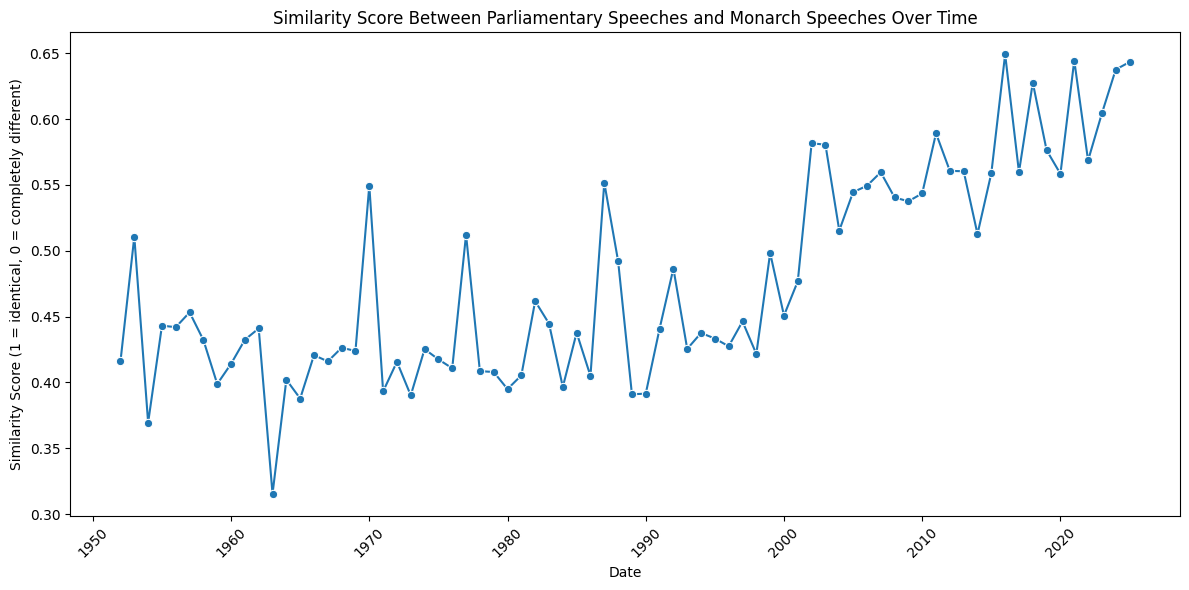

In [64]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, x='year', y='similarity_score', marker='o')
plt.title('Similarity Score Between Parliamentary Speeches and Monarch Speeches Over Time')
plt.xlabel('Date')
plt.ylabel('Similarity Score (1 = identical, 0 = completely different)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [66]:
final_df['month'] = pd.to_datetime(final_df['date']).dt.to_period('M')
monthly_avg = final_df.groupby('month')['similarity_score'].mean().reset_index()
print(monthly_avg.to_string(index=False))

  month  similarity_score
1952-01          0.415575
1952-02          0.389167
1952-03          0.424608
1952-04          0.407329
1952-05          0.418425
1952-06          0.412971
1952-07          0.420251
1952-08          0.448966
1952-10          0.417659
1952-11          0.429111
1952-12          0.415291
1953-01          0.496769
1953-02          0.507569
1953-03          0.516007
1953-04          0.504473
1953-05          0.516221
1953-06          0.506956
1953-07          0.515476
1953-10          0.523176
1953-11          0.506358
1953-12          0.511261
1954-01          0.373231
1954-02          0.364228
1954-03          0.369951
1954-04          0.374870
1954-05          0.362399
1954-06          0.361203
1954-07          0.371427
1954-10          0.376310
1954-11          0.371541
1954-12          0.370515
1955-01          0.443419
1955-02          0.449831
1955-03          0.453132
1955-04          0.453281
1955-05          0.442221
1955-06          0.412530
1955-07     

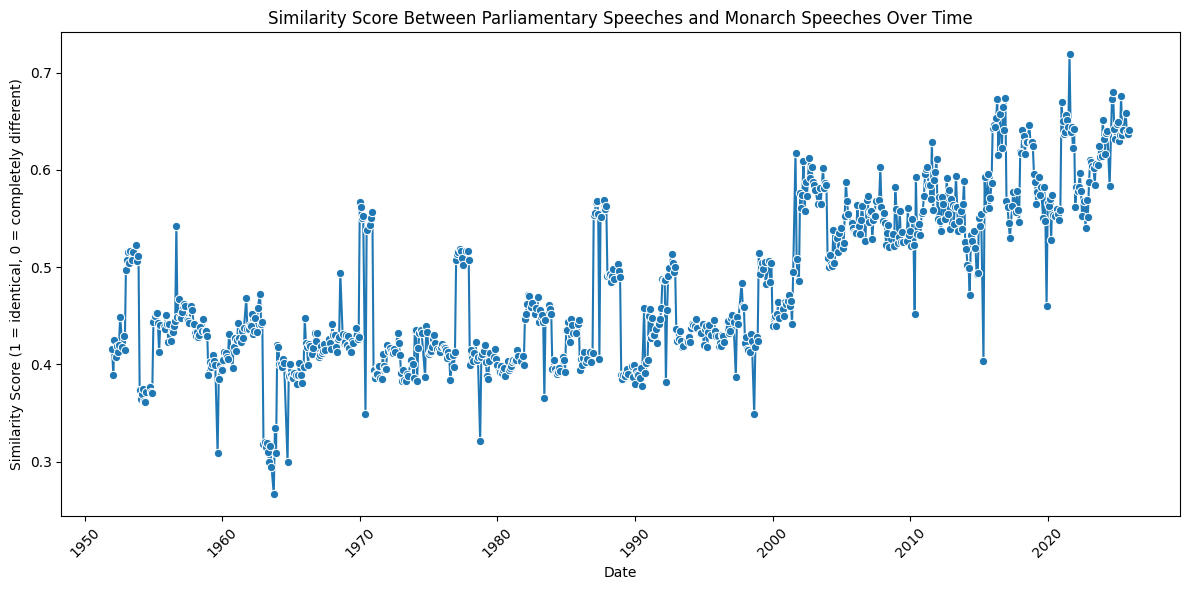

In [68]:
monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='month', y='similarity_score', marker='o')
plt.title('Similarity Score Between Parliamentary Speeches and Monarch Speeches Over Time')
plt.xlabel('Date')
plt.ylabel('Similarity Score (1 = identical, 0 = completely different)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

In [ ]:
# 1. Get the exact date of the royal speech for each year
# We take the first occurrence in case the speech spanned multiple rows
speech_dates = royal_speeches.groupby('year')['date'].first().reset_index()
speech_dates = speech_dates.rename(columns={'date': 'speech_date'})

# 2. Merge these speech dates back into your main daily dataframe
final_df = pd.merge(final_df, speech_dates, on='year', how='left')

# 3. Calculate the 'time' variable (days relative to the speech)
final_df['time'] = (final_df['date'] - final_df['speech_date']).dt.days

# 4. Create the 'post' dummy variable (1 if after the speech, 0 if before)
# Note: We strictly use > 0 so the exact day of the speech (0) isn't counted as a "reaction" day
final_df['post'] = (final_df['time'] > 0).astype(int)

# 5. Create the interaction term to measure the change in momentum
final_df['time_x_post'] = final_df['time'] * final_df['post']

# Check your final, regression-ready dataset!
print(final_df[['date', 'speech_date', 'time', 'post', 'time_x_post', 'similarity_score']].head(10))

        date speech_date  time  post  time_x_post  similarity_score
0 1952-01-29  1952-12-25  -331     0            0          0.408058
1 1952-01-30  1952-12-25  -330     0            0          0.415588
2 1952-01-31  1952-12-25  -329     0            0          0.423077
3 1952-02-01  1952-12-25  -328     0            0          0.425533
4 1952-02-04  1952-12-25  -325     0            0          0.383813
5 1952-02-05  1952-12-25  -324     0            0          0.420220
6 1952-02-06  1952-12-25  -323     0            0          0.366464
7 1952-02-07  1952-12-25  -322     0            0          0.320576
8 1952-02-08  1952-12-25  -321     0            0          0.215939
9 1952-02-11  1952-12-25  -318     0            0          0.490937


In [49]:
# 1. Define your window size (e.g., 14 days before and after)
window_days = 14

# 2. Filter the dataframe to strictly keep rows within this time boundary
windowed_df = final_df[
    (final_df['time'] >= -window_days) & 
    (final_df['time'] <= window_days)
].copy()

# 3. BEST PRACTICE: Drop the exact day of the event (time == 0)
# Why? The speech happens during the day. Debates on t=0 are a messy mix of 
# "pre-speech" anticipation and "post-speech" immediate reaction. 
# Dropping it creates a clean mathematical break between the pre and post periods.
windowed_df = windowed_df[windowed_df['time'] != 0]

# 4. Check how many rows you have left for your regression
print(f"Dataframe reduced to {len(windowed_df)} valid parliamentary days within the +/- {window_days} day window.")
print(windowed_df['time'].value_counts().sort_index())

Dataframe reduced to 770 valid parliamentary days within the +/- 14 day window.
time
-14    47
-13    49
-12    47
-11    43
-10    42
-9     39
-8     43
-7     48
-6     48
-5     45
-4     35
-3     18
-2     15
-1     15
 1     21
 2     18
 3     14
 4     10
 5     11
 6     14
 7     24
 8     23
 9     20
 10    16
 11    12
 12    11
 13    16
 14    26
Name: count, dtype: int64
